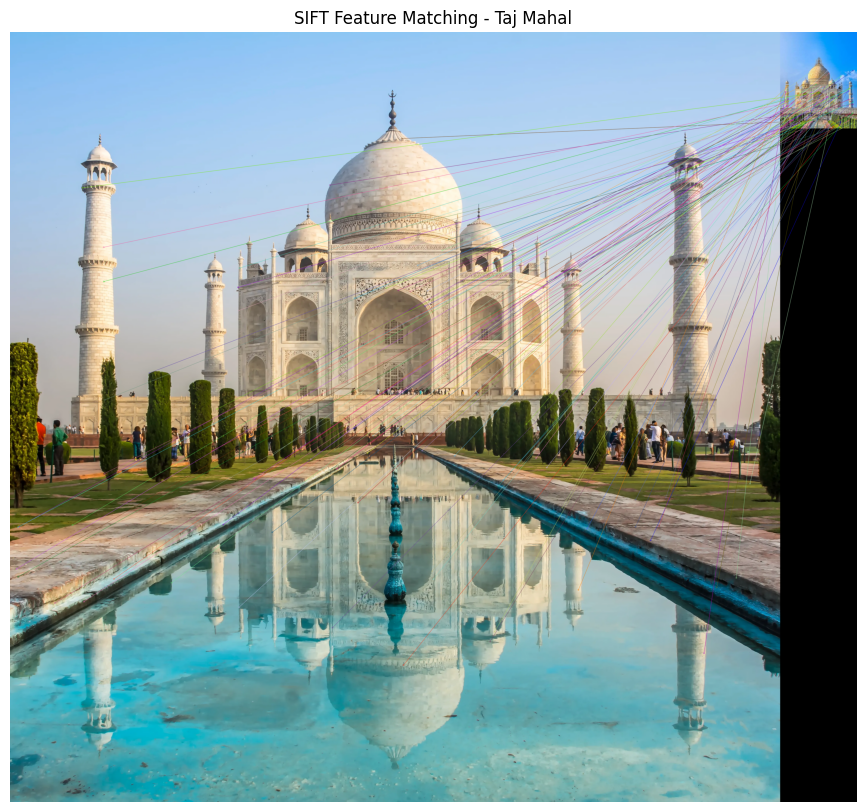

In [1]:
import cv2
import matplotlib.pyplot as plt

# Read the two images
img1 = cv2.imread(r"C:\Users\user\OneDrive\Desktop\taj mahal inmage.webp")
img2 = cv2.imread(r"C:\Users\user\OneDrive\Desktop\Taj mahal image-2.jpg")

if img1 is None or img2 is None:
    print("One of the images was not found!")
else:
    # Convert to grayscale
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Initialize SIFT detector
    sift = cv2.SIFT_create()   # use cv2.xfeatures2d.SIFT_create() if older OpenCV

    # Detect keypoints and descriptors
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    # Use Brute Force matcher
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

    # Match descriptors
    matches = bf.match(des1, des2)

    # Sort matches by distance (best first)
    matches = sorted(matches, key=lambda x: x.distance)

    # Draw top 100 matches
    matched_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:100], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # Show result
    plt.figure(figsize=(15,10))
    plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
    plt.title("SIFT Feature Matching - Taj Mahal")
    plt.axis("off")
    plt.show()
